In [2]:
%load_ext autoreload
%autoreload
import numpy as np
import jax.numpy as jnp
import jax
from jax import jit, vmap
import sys

sys.path.append("../")
import linx.const as const 
from linx.nuclear import NuclearRates
from linx.background import BackgroundModel
from linx.abundances import AbundanceModel

In [3]:
thermo_model_DNeff = BackgroundModel()

(
    t_vec_ref, a_vec_ref, rho_g_vec, rho_nu_vec, rho_NP_vec, P_NP_vec, Neff_vec 
) = thermo_model_DNeff(0.)

`\         /´  ||||        ||||  |||||     ||||  ||||   ||||
 /\_______/\   ||||        ||||  |||||||   ||||   |||| ||||
 ) __` ´__ (   ||||        ||||  |||| |||| ||||    |||||||
/  `-|_|-´  \  ||||        ||||  ||||  |||| |||    ||||||| 
/   (_x_)   \  ||||||||||  ||||  ||||   |||||||   |||| ||||
  )  `-´  (    ||||||||||  ||||  ||||    ||||||  ||||   ||||
 
Compiling thermodynamics model...


In [4]:
network = 'key_PRIMAT_2023'
# network = 'key_PRIMAT_2018'
# network = 'key_PArthENoPE'
# network = 'key_YOF'
abundance_model = AbundanceModel(NuclearRates(nuclear_net=network))

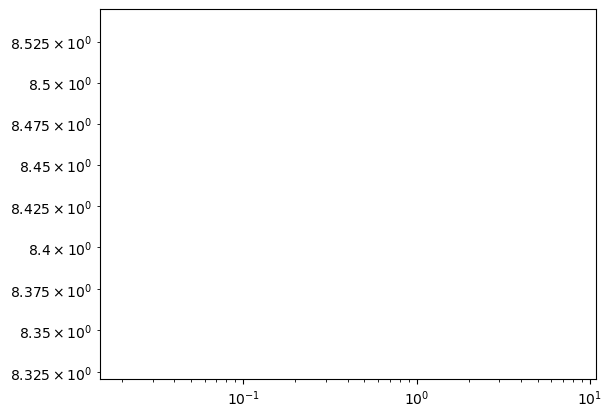

In [ ]:
import linx.thermo as thermo
import matplotlib.pyplot as plt
import linx.const as const

me = const.me

mu_nue = [0.0, 0.1, 1.0]
mu_numt = [0.0, 0.1, 1.0]
for mu_nue, mu_numt in zip(mu_nue, mu_numt):
    T_g = thermo.T_g(rho_g_vec)
    T_nue = [8.0, 1.0, 0.02]
    T_numt = [8.0, 1.0, 0.02]
    for T_g, T_nue, T_numt in zip(T_g, T_nue, T_numt):
        out = thermo.collision_terms_std(
            T_g=T_g,
            T_nue=T_nue,
            T_numt=T_numt,
            mu_nue=mu_nue,
            mu_numt=mu_numt,
            decoupled=False,
            use_FD=True,
            collision_me=True,
        )

        C_rho_nue, C_rho_numu, C_n_nue, C_n_numu = out
        drho_EM_dT_g = thermo.drho_EM_dT_g_std(T_g, me=me)
        drho_nu_dT_nu = thermo.drho_nue_dT_nue_std(T_nue)

        plt.plot(T_nue, T_g, label=r"$C_{\rho_{\nu_e}}$")

        #print("C_rho_nue (for T_g={:.1f}, T_nue={:.1f}, T_numt={:.1f}, mu_nue={:.1f}, mu_numt={:.1f})=".format(T_g, T_nue, T_numt, mu_nue, mu_numt), C_rho_nue)
        #print("C_rho_numu (for T_g={:.1f}, T_nue={:.1f}, T_numt={:.1f}, mu_nue={:.1f}, mu_numt={:.1f})=".format(T_g, T_nue, T_numt, mu_nue, mu_numt), C_rho_numu)
        

        #print("drho_EM/dT_g (for T_g={:.1f}, T_nue={:.1f}, T_numt={:.1f}, mu_nue={:.1f}, mu_numt={:.1f})=".format(T_g, T_nue, T_numt, mu_nue, mu_numt), drho_EM_dT_g)
        #print("drho_nu/dT_nu (for T_g={:.1f}, T_nue={:.1f}, T_numt={:.1f}, mu_nue={:.1f}, mu_numt={:.1f})=".format(T_g, T_nue, T_numt, mu_nue, mu_numt), drho_nu_dT_nu)

        #print("C_n_nue (for T_g={:.1f}, T_nue={:.1f}, T_numt={:.1f}, mu_nue={:.1f}, mu_numt={:.1f})=".format(T_g, T_nue, T_numt, mu_nue, mu_numt), C_n_nue)

In [18]:
#thermo quantities (neutrino temp, photon energy density) versus photon temperature. choose nonzero mus


Finished constructing interpolation functions.                 
 solve system from T_ini = 10.000 to T_fin = 0.009 [MeV]
 --> t_ini = 7.39E-03 [s] to t_fin = 1.63E+04 [s]

Progress: 100.000 %

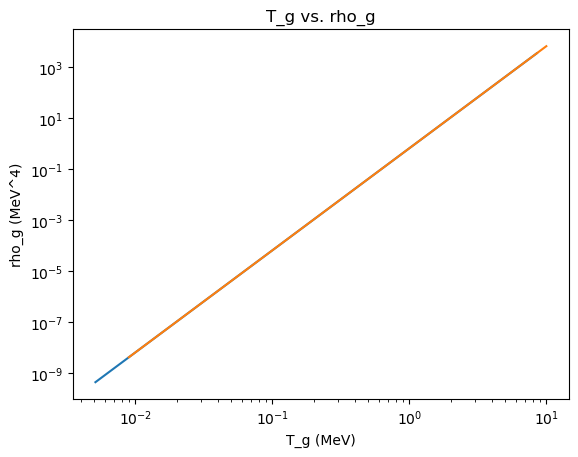

In [23]:
import sys
sys.path.append(r"C:\Users\grace\nudec_BSM\BasicModules_source")
import nudec_v2
nudec = nudec_v2.NuDec()

import time
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

#import BasicModules_source.nudec_v2

#nudec_source = reload(BasicModules_source.nudec_v2)


T_g = thermo.T_g(rho_g_vec)
plt.loglog(T_g, rho_g_vec, label=r"$\rho_\gamma$")


plt.title("T_g vs. rho_g")
plt.xlabel("T_g (MeV)")
plt.ylabel("rho_g (MeV^4)")

t_nudec, y_nudec = nudec.evolve()

T_g_nudec = y_nudec[0]

rho_g_nudec = (np.pi**2 / 15) * T_g_nudec**4

plt.loglog(T_g_nudec, rho_g_nudec, label="NuDec")

Finished constructing interpolation functions.                 rho_nue_std= [Array(0.02538031, dtype=float64, weak_type=True), Array(0.03154887, dtype=float64, weak_type=True), Array(0.04960956, dtype=float64, weak_type=True), Array(0.08379177, dtype=float64, weak_type=True), Array(0.140427, dtype=float64, weak_type=True), Array(0.22753964, dtype=float64, weak_type=True), Array(0.35466176, dtype=float64, weak_type=True), Array(0.53276147, dtype=float64, weak_type=True), Array(0.77421426, dtype=float64, weak_type=True), Array(1.09279044, dtype=float64, weak_type=True)]
rho_nue_nudec= [np.float64(0.025380307425122914), np.float64(0.03154887023860299), np.float64(0.049609552386488426), np.float64(0.0837917410801468), np.float64(0.1404269050871636), np.float64(0.22753941648258197), np.float64(0.3546612930175843), np.float64(0.5327606213566303), np.float64(0.7742128242095982), np.float64(1.0927881535123134)]


Text(0.5, 1.0, 'rho_nue vs. T_nue for mu_nue=1')

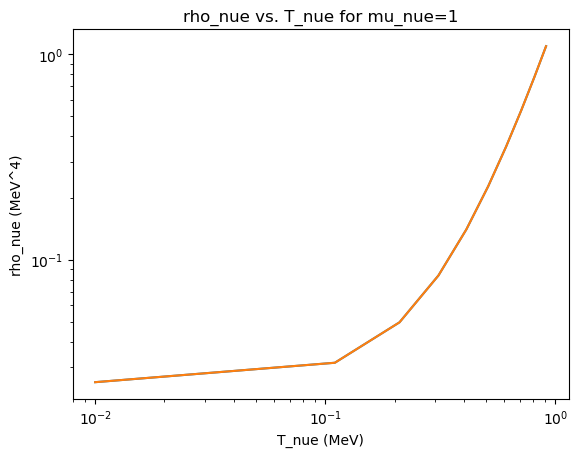

In [71]:
import sys
sys.path.append(r"C:\Users\grace\nudec_BSM\BasicModules_source")
import nudec_v2
nudec = nudec_v2.NuDec()

import time
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

mu=1

T_nue = np.arange(0.01, 1, 0.1)
rho_nue_std = []
rho_nue_nudec = []
for T in T_nue:
    rho_nue_linx = thermo.rho_nue_std(T, mu)
    rho_nue_nudecbsm = nudec.thermo.Rho_FD(T, mu)
    rho_nue_std.append(rho_nue_linx)
    rho_nue_nudec.append(rho_nue_nudecbsm)
print("rho_nue_std=", rho_nue_std)
print("rho_nue_nudec=", rho_nue_nudec)

plt.loglog(T_nue, rho_nue_std, label="rho_nue_std")
plt.loglog(T_nue, rho_nue_nudec, label="rho_nue_nudec")

plt.xlabel("T_nue (MeV)")
plt.ylabel("rho_nue (MeV^4)")
plt.title("rho_nue vs. T_nue for mu_nue={}".format(mu))

rho_nue_linx= [0.02538031 0.03154887 0.04960956 0.08379177 0.140427   0.22753964
 0.35466176 0.53276147 0.77421426 1.09279044]
rho_nue_nudec= [0.02538031 0.03154887 0.04960955 0.08379174 0.14042691 0.22753942
 0.35466129 0.53276062 0.77421282 1.09278815]
rho_nue_residuals= [1.31626872e-12 1.55039714e-08 1.30968819e-07 3.68215112e-07
 6.72266008e-07 9.93299208e-07 1.30425018e-06 1.59349267e-06
 1.85788175e-06 2.09656629e-06]


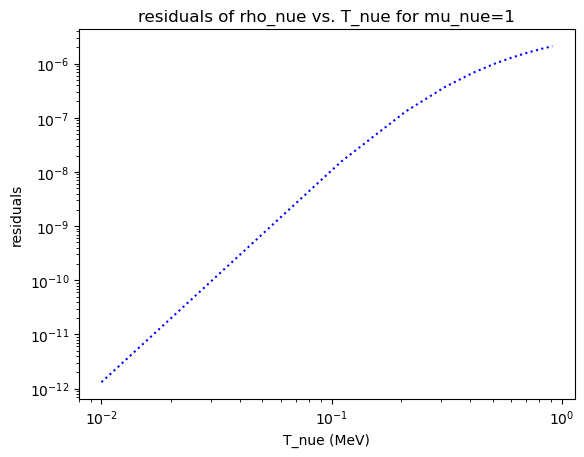

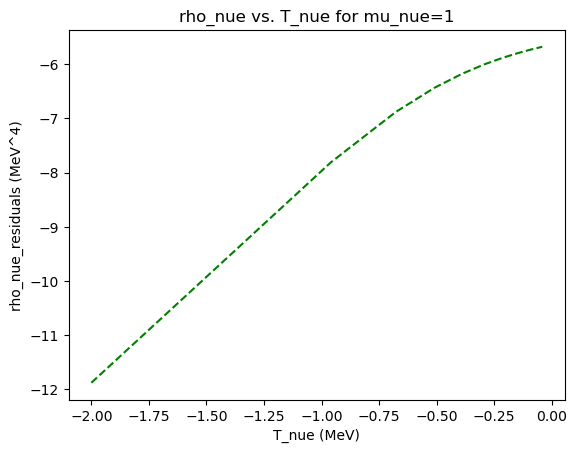

In [83]:

print("rho_nue_linx=", np.array(rho_nue_std))
print("rho_nue_nudec=", np.array(rho_nue_nudec))



rho_nue_difference = np.array(rho_nue_std) - np.array(rho_nue_nudec) 
rho_nue_residuals = rho_nue_difference / np.array(rho_nue_nudec)
print("rho_nue_residuals=", rho_nue_residuals)
plt.loglog(T_nue, rho_nue_residuals, label="residuals", color='blue', linestyle='dotted')
plt.xlabel("T_nue (MeV)")
plt.ylabel("residuals")
plt.title("residuals of rho_nue vs. T_nue for mu_nue={}".format(mu))
plt.show()

T_nue_log = np.log10(T_nue)
rho_nue_residuals_log = np.log10(rho_nue_residuals)

plt.plot(T_nue_log, rho_nue_residuals_log, label="rho_nue_std, reconstructed log plot",color='green', linestyle='dashed')
plt.xlabel("T_nue (MeV)")
plt.ylabel("rho_nue_residuals (MeV^4)")
plt.title("rho_nue vs. T_nue for mu_nue={}".format(mu))

plt.show()

Text(0.5, 1.0, 'rho_nue vs. T_nue for mu_nue=1, linear plot')

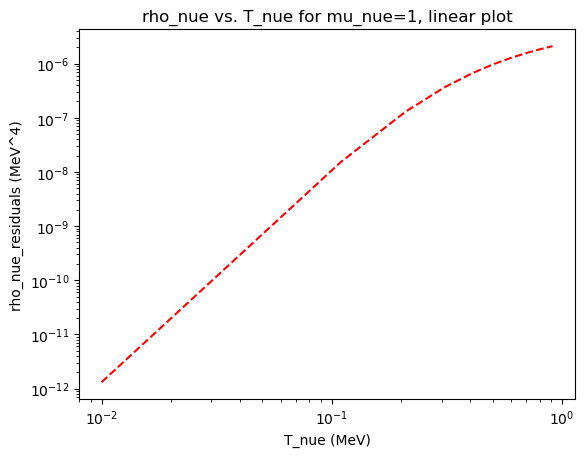

In [89]:
plt.loglog(T_nue, rho_nue_residuals, label="rho_nue_std, reconstructed",color='red', linestyle='dashed')
plt.xlabel("T_nue (MeV)")
plt.ylabel("rho_nue_residuals (MeV^4)")
plt.title("rho_nue vs. T_nue for mu_nue={}, linear plot".format(mu))